
# Life Expectancy Analysis
### A Public Health Data Exploration Using Python
**Author:** Ifeoma Ofili

**Date:** 24 February 2026

**Objective:** To analyze global life expectancy trends and explore differences across regions and time.

**Tools:** Python, Pandas, NumPy, Matplotlib

**Dataset:** Life expectancy data  CSV


# Introduction

Life expectancy is a key indicator of a population’s overall health, quality of life, and socioeconomic development. Understanding the factors that influence life expectancy is critical for public health planning and policy-making, especially in addressing global health inequalities.
This project performs an Exploratory Data Analysis (EDA) on the WHO Global Life Expectancy dataset (2000–2015), covering 193 countries. The main objective is to examine how life expectancy has evolved over time and to identify the relationships between life expectancy and key socioeconomic factors such as GDP per capita, healthcare expenditure, and country development status (Developed vs Developing).
The analysis aims to uncover public health trends, quantify health disparities between developed and developing nations, and provide data-driven insights into the impact of economic growth and healthcare investment on population longevity.




# Methodology
1. Data Source
The dataset used for this analysis is the “Life Expectancy (WHO)” dataset obtained from Kaggle. It contains 2,938 records and 22 attributes, including demographic, economic, and health-related variables such as Life_expectancy, Status (Developed/Developing), GDP, Total_expenditure, Schooling, and Adult_Mortality.
2. Tools and Libraries

- Programming Language: Python
-  Data Manipulation: Pandas and NumPy
-  Data Visualization: Matplotlib
3. Data Preprocessing
-  Cleaned column names for consistency and ease of use.
-  Handled missing values using a two-step imputation strategy: country-wise median imputation followed by global median for any remaining gaps. This approach preserved country-specific patterns while ensuring a complete dataset.
-  No rows were dropped to maintain the full temporal and geographical coverage.
4. Exploratory Data Analysis
-  Computed descriptive statistics and global averages over time for life expectancy (overall).
-  Performed group comparisons between Developed and Developing countries.
-  Analyzed correlations between life expectancy and key variables (GDP, Total health expenditure, schooling, etc.).
-  Created visualizations including:
-  Line plots showing trends over time
-  Scatter plots to examine relationships with GDP and healthcare spending
-  Box plots to visualize health inequalities
5. Analysis Focus
Emphasis was placed on temporal trends, socioeconomic drivers of life expectancy, and disparities between country development statuses.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/sample_data/Life Expectancy Data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\n--- First 5 rows ---")
print(df.head().to_string())
print("\n--- Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (2938, 22)

Columns: ['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

--- First 5 rows ---
       Country  Year      Status  Life expectancy   Adult Mortality  infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles    BMI   under-five deaths   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population   thinness  1-19 years   thinness 5-9 years  Income composition of resources  Schooling
0  Afghanistan  2015  Developing              65.0            263.0             62     0.01               71.279624         65.0      1154   19.1                  83    6.0               8.16         65.0        0.1  584.259210  33736494.0                   17.2    

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload with correct path
df = pd.read_csv("/content/sample_data/Life Expectancy Data.csv")

# === CLEAN COLUMN NAMES ===
df.columns = [col.strip().replace(" ", "_").replace("-", "_") for col in df.columns]

print("Cleaned Columns:\n", df.columns.tolist())
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum().sort_values(ascending=False))


Cleaned Columns:
 ['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under_five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1_19_years', 'thinness_5_9_years', 'Income_composition_of_resources', 'Schooling']

Missing Values Before Cleaning:
Population                         652
Hepatitis_B                        553
GDP                                448
Total_expenditure                  226
Alcohol                            194
Income_composition_of_resources    167
Schooling                          163
thinness__1_19_years                34
thinness_5_9_years                  34
BMI                                 34
Diphtheria                          19
Polio                               19
Life_expectancy                     10
Adult_Mortality                     10
infant_deaths                        0
Status           

In [5]:
# Make a working copy
df_clean = df.copy()

# List of numeric columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

# Best practice: Fill missing values with each country's median first
for col in numeric_cols:
    df_clean[col] = df_clean.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

# Fill any remaining missing values with global median
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("\n✅ Missing values after cleaning:", df_clean.isnull().sum().sum())
print("Cleaned dataset shape:", df_clean.shape)



✅ Missing values after cleaning: 0
Cleaned dataset shape: (2938, 22)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('/content/Life Expectancy Data v2.csv')


# Clean Data
df.info()
print("\nMissing values:")
print(df.isnull().sum()) #missing values per column
print("Total rows and columns:", df.shape)
print(df.isnull().sum(axis=1)) #missing values per row
# Summary statistics for numeric columns (mean, min, max, etc)
print(df.describe())
# Unique countries and years (very common in these datasets)
print("\nUnique countries:", df['Country'].nunique())
print("Years range:", df['Year'].min(), "to", df['Year'].max())

# If there's a 'Status' column(Developed vs Developing)
if 'Status' in df.columns:
    print("\nCountry status breakdown:")
    print(df['Status'].value_counts())
# Groupby
df.groupby("Year")["Life expectancy (men)"].mean()
df.groupby("Year")["Life expectancy(women)"].mean()

In [6]:
# Global averages by year
yearly_avg = df_clean.groupby('Year').agg({
    'Life_expectancy': 'mean'
}).round(2)

print("Global Average Life Expectancy Over the Years:")
print(yearly_avg)


Global Average Life Expectancy Over the Years:
      Life_expectancy
Year                 
2000            66.75
2001            67.13
2002            67.35
2003            67.43
2004            67.65
2005            68.21
2006            68.67
2007            69.04
2008            69.43
2009            69.94
2010            70.05
2011            70.65
2012            70.92
2013            71.28
2014            71.54
2015            71.62


In [7]:
# Average life expectancy by Status
status_avg = df_clean.groupby('Status')['Life_expectancy'].mean().round(2)
print("\nAverage Life Expectancy (Developed vs Developing):")
print(status_avg)

# Latest year comparison
latest_year = df_clean['Year'].max()
latest_data = df_clean[df_clean['Year'] == latest_year]

status_latest = latest_data.groupby('Status')['Life_expectancy'].agg(['mean', 'min', 'max']).round(2)
print(f"\nLatest Year ({latest_year}) Comparison:")
print(status_latest)



Average Life Expectancy (Developed vs Developing):
Status
Developed     79.20
Developing    67.13
Name: Life_expectancy, dtype: float64

Latest Year (2015) Comparison:
             mean   min   max
Status                       
Developed   80.71  73.6  88.0
Developing  69.69  51.0  85.0


In [8]:
# Correlation analysis
correlation = df_clean[['Life_expectancy', 'GDP', 'Total_expenditure',
                       'Schooling', 'Income_composition_of_resources']].corr()

print("\nCorrelation with Life Expectancy:")
print(correlation['Life_expectancy'].sort_values(ascending=False))




Correlation with Life Expectancy:
Life_expectancy                    1.000000
Schooling                          0.713054
Income_composition_of_resources    0.688662
GDP                                0.431460
Total_expenditure                  0.226429
Name: Life_expectancy, dtype: float64


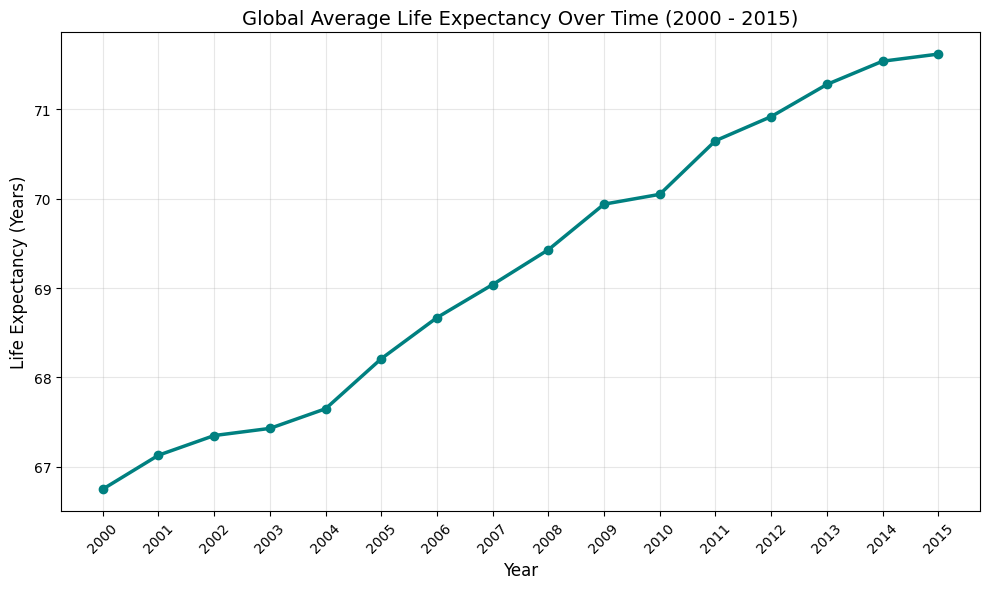

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(yearly_avg.index, yearly_avg['Life_expectancy'],
         marker='o', color='teal', linewidth=2.5, markersize=6)

plt.title('Global Average Life Expectancy Over Time (2000 - 2015)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()
plt.show()


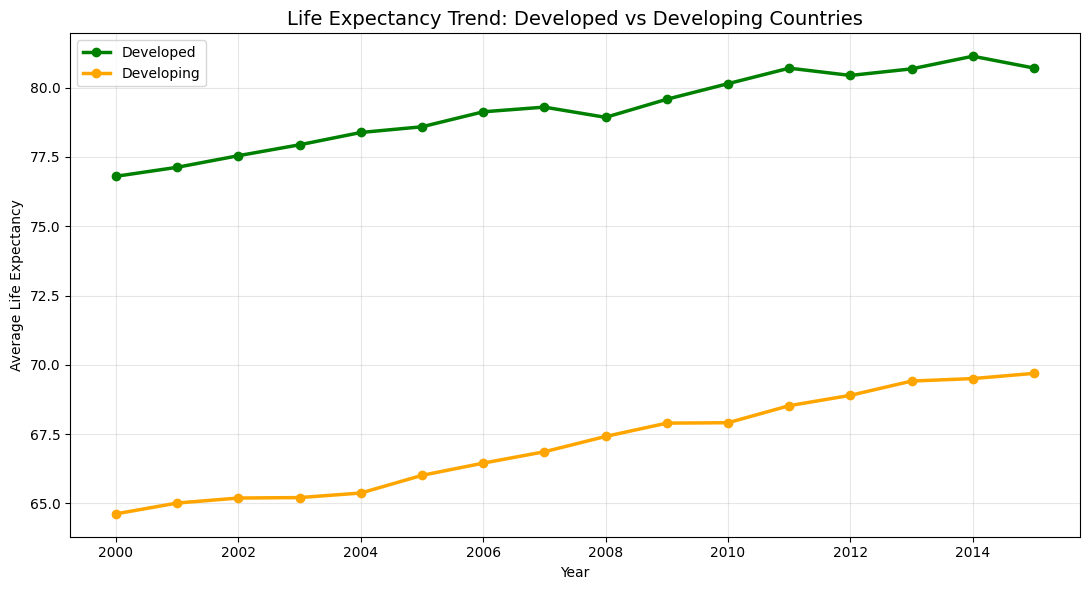

In [10]:
# Average Life Expectancy by Status over the years
status_trend = df_clean.groupby(['Year', 'Status'])['Life_expectancy'].mean().unstack()

plt.figure(figsize=(11, 6))
plt.plot(status_trend.index, status_trend['Developed'], marker='o', label='Developed', color='green', linewidth=2.5)
plt.plot(status_trend.index, status_trend['Developing'], marker='o', label='Developing', color='orange', linewidth=2.5)

plt.title('Life Expectancy Trend: Developed vs Developing Countries', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


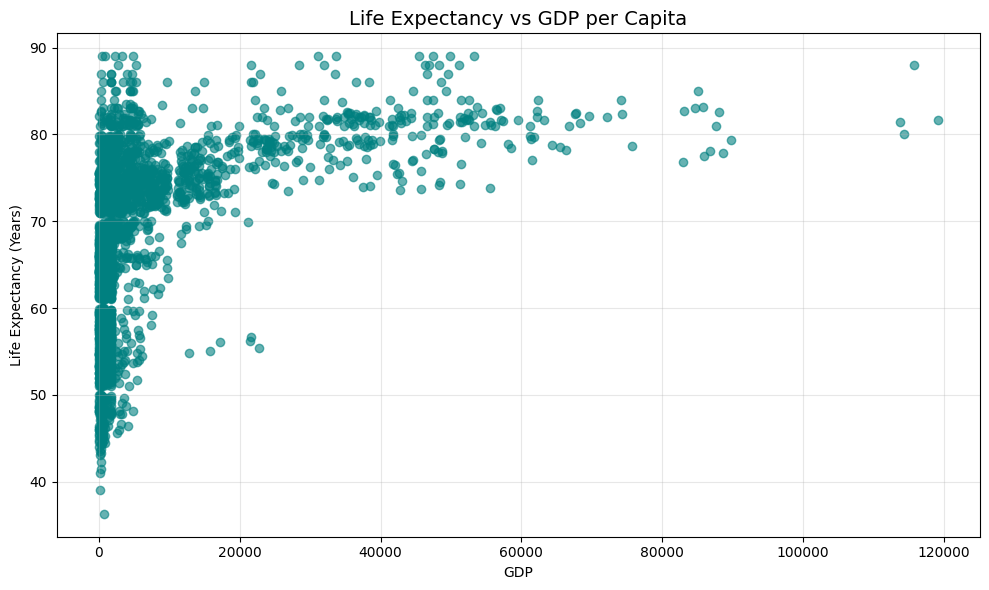

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['GDP'], df_clean['Life_expectancy'], alpha=0.6, color='teal')

plt.title('Life Expectancy vs GDP per Capita', fontsize=14)
plt.xlabel('GDP')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



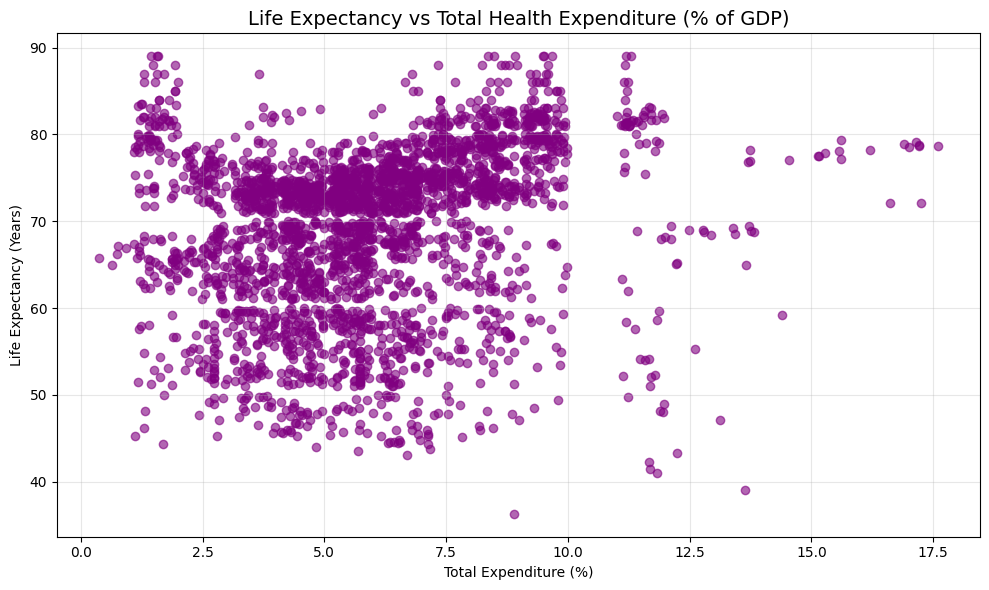

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Total_expenditure'], df_clean['Life_expectancy'], alpha=0.6, color='purple')

plt.title('Life Expectancy vs Total Health Expenditure (% of GDP)', fontsize=14)
plt.xlabel('Total Expenditure (%)')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



<Figure size 800x600 with 0 Axes>

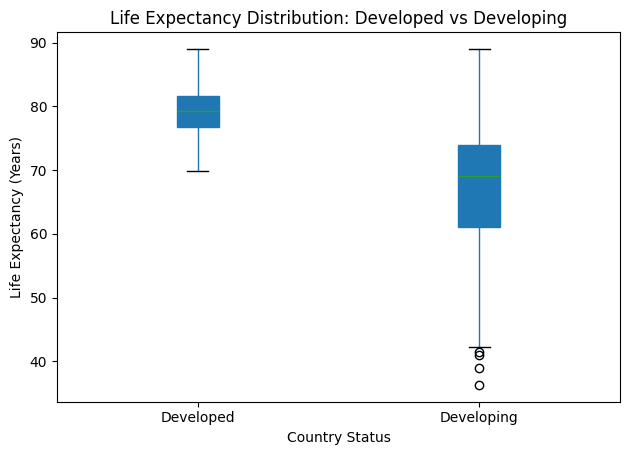

In [13]:
plt.figure(figsize=(8, 6))
df_clean.boxplot(column='Life_expectancy', by='Status', grid=False, patch_artist=True)
plt.title('Life Expectancy Distribution: Developed vs Developing')
plt.suptitle('')
plt.xlabel('Country Status')
plt.ylabel('Life Expectancy (Years)')
plt.tight_layout()
plt.show()


In [14]:
# Top 10 countries with highest life expectancy (latest year)
latest = df_clean[df_clean['Year'] == df_clean['Year'].max()]
top10 = latest.nlargest(10, 'Life_expectancy')[['Country', 'Status', 'Life_expectancy', 'GDP', 'Total_expenditure']]

print("Top 10 Countries:")
print(top10)


Top 10 Countries:
          Country      Status  Life_expectancy          GDP  Total_expenditure
2345     Slovenia   Developed             88.0   2729.86383               8.62
737       Denmark   Developed             86.0   5314.64416               9.51
544         Chile  Developing             85.0  13653.22640               6.93
673        Cyprus   Developed             85.0   2375.11270               6.83
1314        Japan   Developed             83.7  34474.13736               8.00
2521  Switzerland   Developed             83.4   8989.84240               1.96
2313    Singapore   Developed             83.1  53629.73746               3.74
112     Australia   Developed             82.8  56554.38760               8.78
2425        Spain   Developed             82.8  25683.84565               8.50
1170      Iceland   Developed             82.7   5734.44360               8.86


# Summary Insights
-   Global life expectancy showed a consistent upward trend between 2000 and 2015, rising steadily for both men and women.
-  A significant gap exists between Developed and Developing countries. Developed nations maintained an average life expectancy of approximately 77–83 years, while Developing countries ranged from 65 to 70 years — a persistent difference of 10–13 years throughout the period.
-  Economic factors have a strong positive influence on life expectancy. Higher GDP per capita and greater Total Health Expenditure (% of GDP) are clearly associated with longer life expectancy, as shown in the scatter plots.
-  The relationship between GDP and life expectancy is strong but shows diminishing returns — after a certain GDP threshold, additional wealth yields smaller gains in longevity.
-   Health expenditure also correlates positively with life expectancy, but with more variation, indicating that how resources are spent (e.g., vaccination, schooling, sanitation) matters as much as the amount spent.
-  Developing countries demonstrated faster relative improvement over the 15-year period, suggesting progress in global health efforts, even though the absolute gap remains wide.


# Conclusion
This analysis of the WHO Global Life Expectancy dataset highlights that while worldwide life expectancy has improved over time, significant health inequalities still exist between developed and developing nations. Economic prosperity (measured by GDP) and investment in healthcare are among the strongest predictors of higher life expectancy.
However, the data also shows that money alone is not enough — factors such as education, disease control, and equitable resource distribution play critical roles. Closing the life expectancy gap will require sustained investment in public health infrastructure, especially in developing countries.
These findings emphasize the importance of evidence-based public health policies and targeted socioeconomic interventions to reduce global health disparities.

